# Compound Distributions

This notebook demonstrates how simple distributions (Gaussian, Uniform, Exponential) combine into compound distributions via:
- **`add(d1, d2)`** — distribution of X + Y for any two distributions
- **`sum_of_n(d, n)`** — distribution of X₁ + X₂ + … + Xₙ (iid copies)

PDFs are estimated via kernel density estimation over 200k Monte Carlo samples.

In [4]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats

from distributions import Gaussian, Uniform, Exponential,TwoPoint, add, sum_of_n

plt.style.use('seaborn-v0_8-darkgrid')
COLORS = plt.rcParams['axes.prop_cycle'].by_key()['color']
OUTPUTS = 'outputs'

import os; os.makedirs(OUTPUTS, exist_ok=True)
print('Imports OK')

Imports OK


## Helper: plot a distribution

In [5]:
def plot_dist(dist, ax, label=None, color=None, n_samples=1_000_000, bins=200):
    """Plot histogram of samples + KDE pdf curve on ax."""
    samples = dist.sample(n_samples)
    lo, hi = np.percentile(samples, [0.5, 99.5])
    x = np.linspace(lo, hi, 500)
    ax.hist(samples, bins=bins, density=True, alpha=0.35, color=color)
    ax.plot(x, dist.pdf(x), lw=2, color=color, label=label or repr(dist))
    ax.set_xlim(lo, hi)

---
## 1  Sum of N Uniform distributions (Central Limit Theorem)

U(0,1) has mean 0.5, variance 1/12.  
Sum of N copies → Normal(N/2, N/12) as N → ∞.

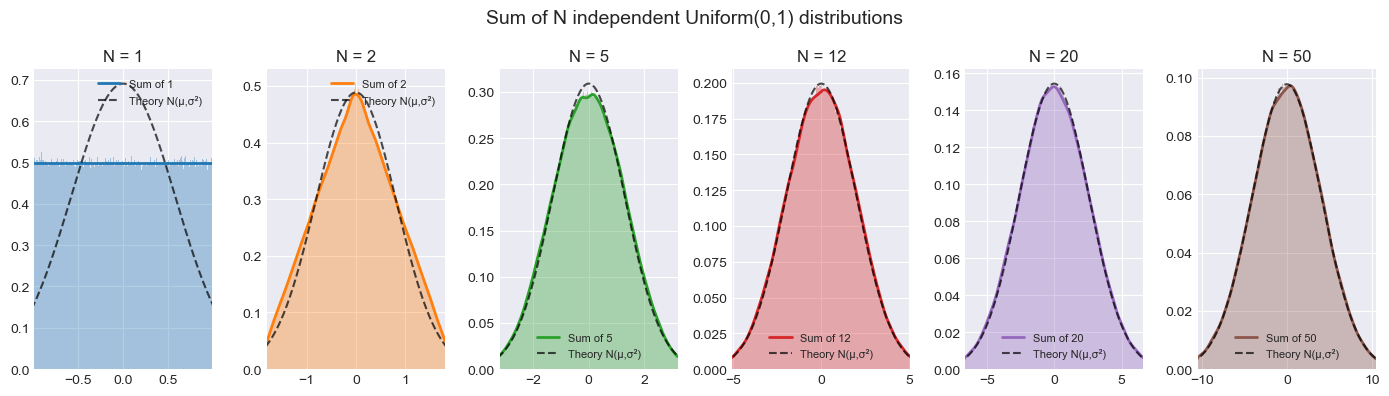

Saved → outputs/sum_of_n_uniform.png


In [22]:
u = Uniform(-1,1)
ns = [1, 2, 5, 12,20,50]

fig, axes = plt.subplots(1, len(ns), figsize=(14, 4), sharey=False)
fig.suptitle('Sum of N independent Uniform(0,1) distributions', fontsize=14)

for ax, n, color in zip(axes, ns, COLORS):
    d = sum_of_n(u, n) if n > 1 else u
    plot_dist(d, ax, label=f'Sum of {n}', color=color)

    # Overlay theoretical normal for reference
    mu_theory = 0
    sigma_theory = np.sqrt(n*4/12)
    x = np.linspace(mu_theory - 4*sigma_theory, mu_theory + 4*sigma_theory, 400)
    ax.plot(x, stats.norm.pdf(x, mu_theory, sigma_theory),
            'k--', lw=1.5, alpha=0.7, label='Theory N(μ,σ²)')

    ax.set_title(f'N = {n}')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(f'{OUTPUTS}/sum_of_n_uniform.png', dpi=150)
plt.show()
print('Saved → outputs/sum_of_n_uniform.png')

---
## 2  Normal + Uniform

X ~ N(0,1),  Y ~ U(-2, 2).  
The sum broadens and slightly flattens the Gaussian.

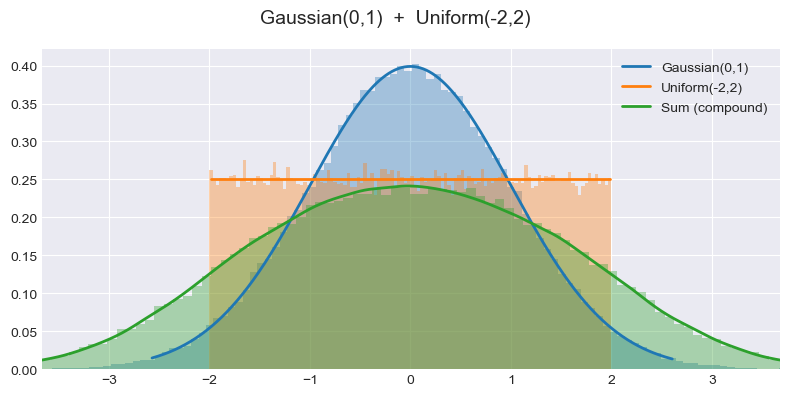

Saved → outputs/gaussian_plus_uniform.png


In [4]:
g = Gaussian(mu=0, sigma=1)
u2 = Uniform(a=-2, b=2)
g_plus_u = add(g, u2)

fig, ax = plt.subplots(figsize=(8, 4))
fig.suptitle('Gaussian(0,1)  +  Uniform(-2,2)', fontsize=14)

plot_dist(g,       ax, label='Gaussian(0,1)',    color=COLORS[0])
plot_dist(u2,      ax, label='Uniform(-2,2)',    color=COLORS[1])
plot_dist(g_plus_u, ax, label='Sum (compound)',  color=COLORS[2])

ax.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUTS}/gaussian_plus_uniform.png', dpi=150)
plt.show()
print('Saved → outputs/gaussian_plus_uniform.png')

---
## 3  Normal + Normal

X ~ N(μ₁,σ₁²), Y ~ N(μ₂,σ₂²) → X+Y ~ N(μ₁+μ₂, σ₁²+σ₂²) exactly.

We verify the Monte Carlo result matches theory.

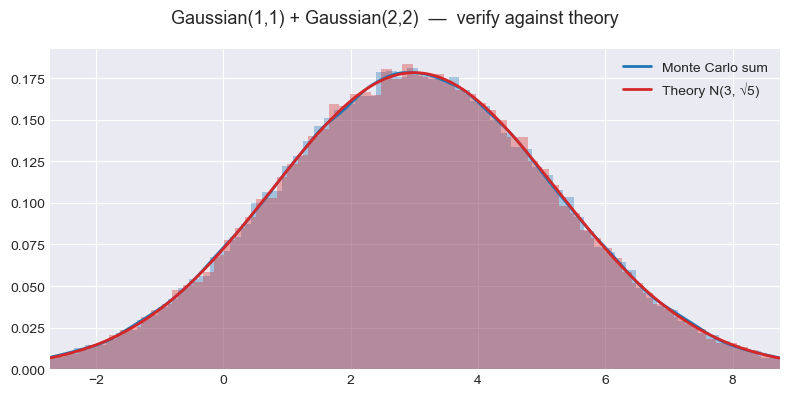

Saved → outputs/gaussian_plus_gaussian.png


In [5]:
g1 = Gaussian(mu=1, sigma=1)
g2 = Gaussian(mu=2, sigma=2)
g_sum = add(g1, g2)

# Theoretical: N(3, 1+4) = N(3, sqrt(5))
theory = Gaussian(mu=3, sigma=np.sqrt(5))

fig, ax = plt.subplots(figsize=(8, 4))
fig.suptitle('Gaussian(1,1) + Gaussian(2,2)  —  verify against theory', fontsize=13)

plot_dist(g_sum,  ax, label='Monte Carlo sum',        color=COLORS[0])
plot_dist(theory, ax, label='Theory N(3, √5)',        color=COLORS[3])

ax.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUTS}/gaussian_plus_gaussian.png', dpi=150)
plt.show()
print('Saved → outputs/gaussian_plus_gaussian.png')

---
## 4  Uniform + Exponential

X ~ U(0,1),  Y ~ Exp(λ=1).  
The sum has a trapezoidal-then-exponential tail shape.

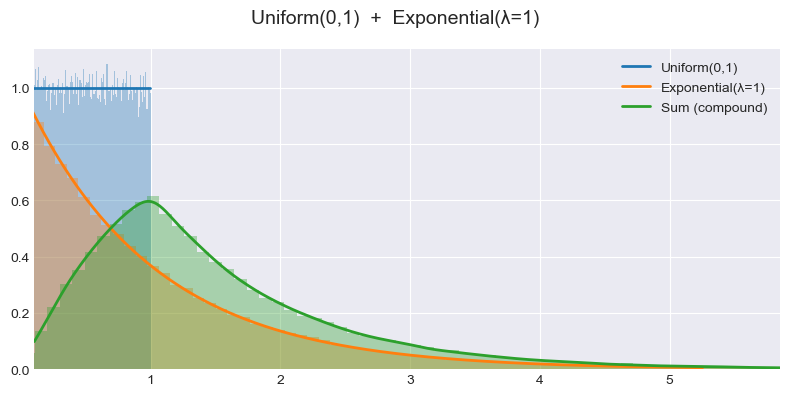

Saved → outputs/uniform_plus_exponential.png


In [6]:
u1 = Uniform(0, 1)
e1 = Exponential(lam=1)
u_plus_e = add(u1, e1)

fig, ax = plt.subplots(figsize=(8, 4))
fig.suptitle('Uniform(0,1)  +  Exponential(λ=1)', fontsize=14)

plot_dist(u1,      ax, label='Uniform(0,1)',     color=COLORS[0])
plot_dist(e1,      ax, label='Exponential(λ=1)', color=COLORS[1])
plot_dist(u_plus_e, ax, label='Sum (compound)',  color=COLORS[2])

ax.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUTS}/uniform_plus_exponential.png', dpi=150)
plt.show()
print('Saved → outputs/uniform_plus_exponential.png')

---
## 5  Chaining: arbitrary compound distributions

`add()` returns a `CompoundDistribution`, which is itself a `Distribution` —  
so you can chain calls freely.

Distribution: ((Gaussian(mu=0, sigma=1) + Uniform(a=-1, b=1)) + Exponential(lam=0.1))


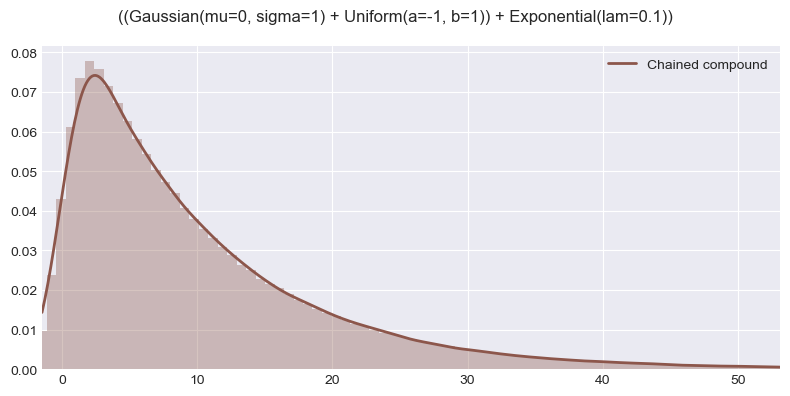

Saved → outputs/chained_compound.png


In [11]:
# Build: Gaussian + Uniform + Exponential  (3-way compound)
d_chain = add(add(Gaussian(0, 1), Uniform(-1, 1)), Exponential(lam=0.1))
print('Distribution:', d_chain)

fig, ax = plt.subplots(figsize=(8, 4))
fig.suptitle(f'{d_chain}', fontsize=12)
plot_dist(d_chain, ax, label='Chained compound', color=COLORS[5])
ax.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUTS}/chained_compound.png', dpi=150)
plt.show()
print('Saved → outputs/chained_compound.png')

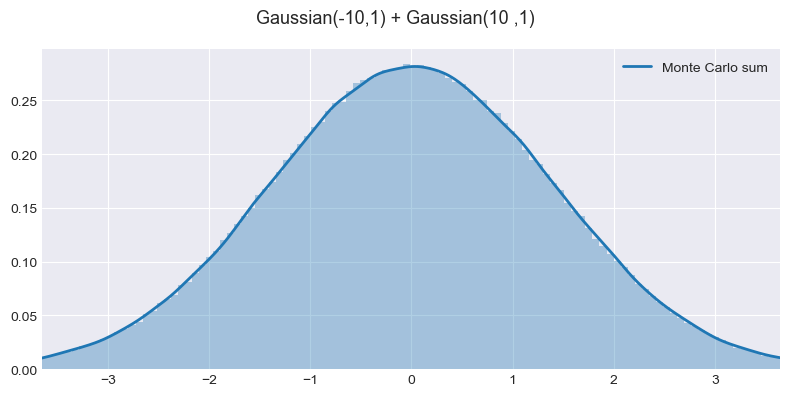

Saved → outputs/gaussian_plus_gaussian.png


In [29]:
g1 = Gaussian(mu=-10, sigma=1)
g2 = Gaussian(mu=10, sigma=1)
g_sum = add(g1, g2)



fig, ax = plt.subplots(figsize=(8, 4))
fig.suptitle('Gaussian(-10,1) + Gaussian(10 ,1)', fontsize=13)

plot_dist(g_sum,  ax, label='Monte Carlo sum',color=COLORS[0])

ax.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUTS}/gaussian_plus_gaussian.png', dpi=150)
plt.show()
print('Saved → outputs/gaussian_plus_gaussian.png')


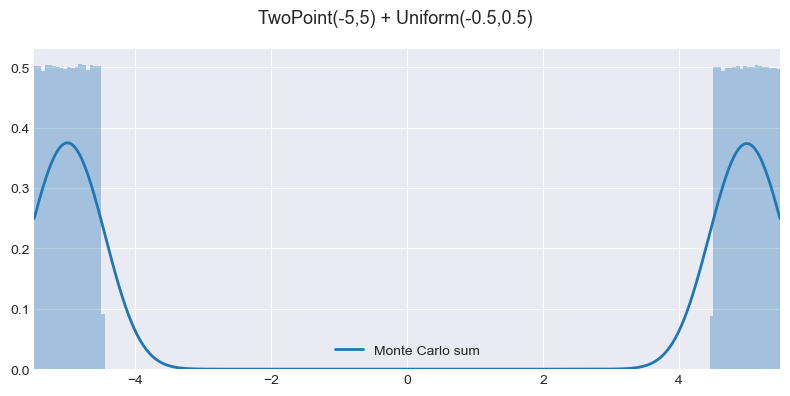

Saved → outputs/gaussian_plus_gaussian.png


In [12]:
g1 = TwoPoint(-5,5)
g2 = Uniform(-0.5,0.5)
g_sum = add(g1, g2)



fig, ax = plt.subplots(figsize=(8, 4))
fig.suptitle('TwoPoint(-5,5) + Uniform(-0.5,0.5)', fontsize=13)

plot_dist(g_sum,  ax, label='Monte Carlo sum',color=COLORS[0])

ax.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUTS}/gaussian_plus_gaussian.png', dpi=150)
plt.show()
print('Saved → outputs/gaussian_plus_gaussian.png')

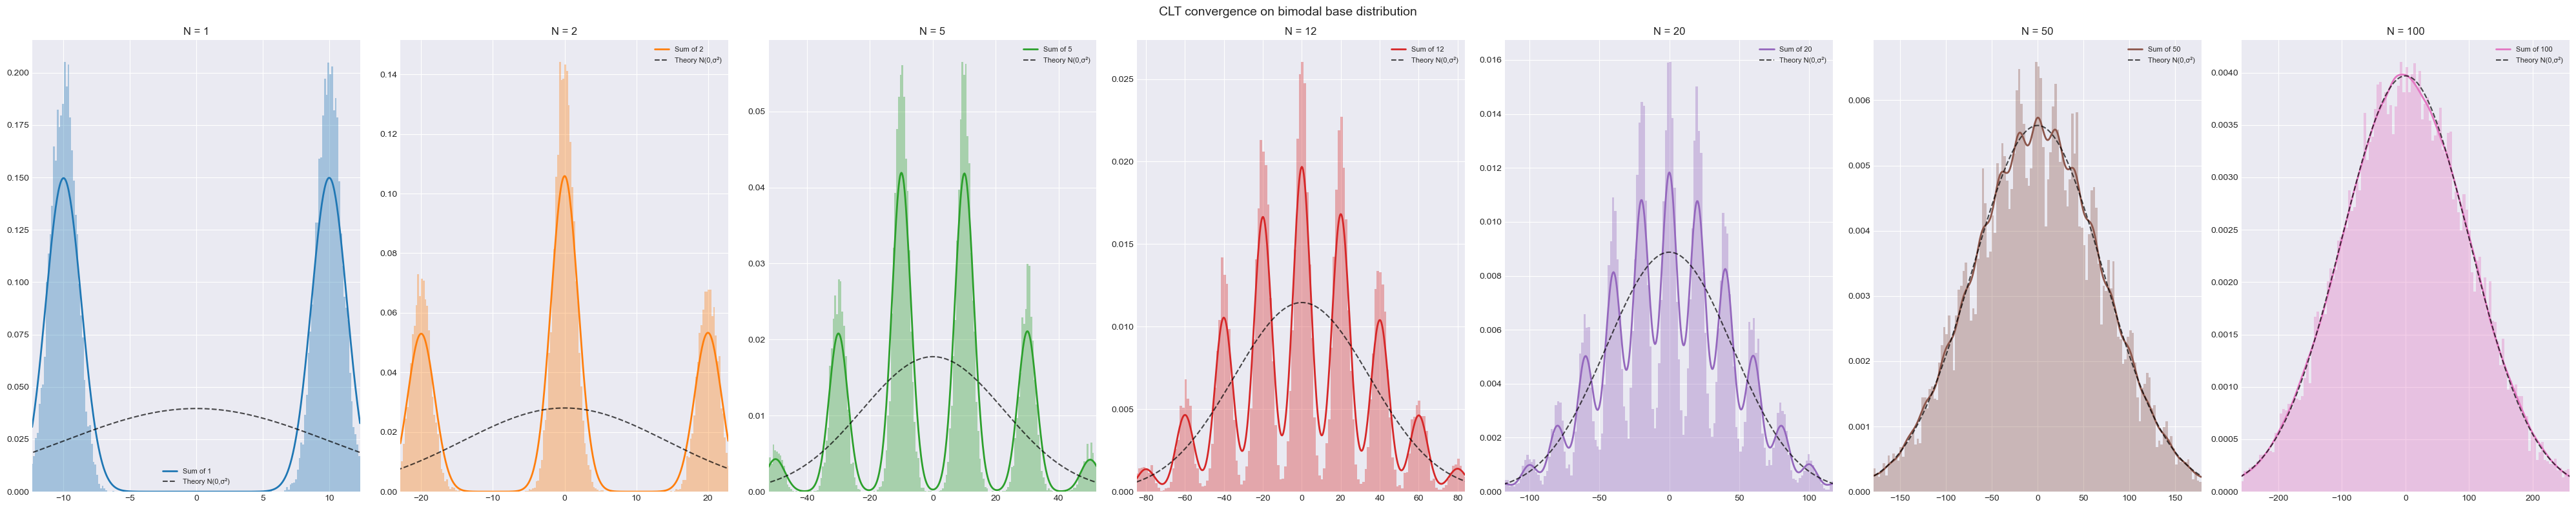

In [10]:
from distributions import Gaussian, TwoPoint, add, sum_of_n

g   = Gaussian(mu=0, sigma=1)
tp  = TwoPoint(a=-10, b=10)
base = add(g, tp)   # Var=101, mean=0 — do NOT wrap in sum_of_n here

ns = [1, 2, 5, 12, 20, 50,100]

fig, axes = plt.subplots(1, len(ns), figsize=(40, 8), sharey=False)
fig.suptitle('CLT convergence on bimodal base distribution', fontsize=14)

for ax, n, color in zip(axes, ns, COLORS):
    dist = sum_of_n(base, n) if n > 1 else base   # single level of nesting
    plot_dist(dist, ax, label=f'Sum of {n}', color=color, n_samples=20_000)

    mu_theory    = 0
    sigma_theory = np.sqrt(n * 101)   # n × Var(base)
    x = np.linspace(mu_theory - 4*sigma_theory, mu_theory + 4*sigma_theory, 400)
    ax.plot(x, stats.norm.pdf(x, mu_theory, sigma_theory),
            'k--', lw=1.5, alpha=0.7, label='Theory N(0,σ²)')

    ax.set_title(f'N = {n}')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(f'{OUTPUTS}/clt_bimodal.png', dpi=150)
plt.show()

---
## Summary

| API | What it does |
|-----|-------------|
| `add(d1, d2)` | X + Y for any two distributions |
| `sum_of_n(d, n)` | X₁+…+Xₙ iid from d |
| Chaining | `add(add(d1, d2), d3)` works freely |

PDF estimation uses KDE over 200k samples — accurate for smooth distributions.  
All plots saved to `outputs/`.